## Testing data loading

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

In [3]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
device

'cuda:1'

In [4]:
from dataset import SuctionGraspingDataset, data_transform

In [ ]:
dataset = SuctionGraspingDataset(
    data_path='../data',
    sample_list='../data/train-split.txt',
    transform=data_transform
)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=False,
)

for color_batch, depth_batch, label_batch in loader:
    print(color_batch.shape) # color_batch:  (B, 3, H, W)
    print(depth_batch.shape) # depth_batch:  (B, 3, H, W)
    print(label_batch.shape) # label_batch:  (B, H//8, W//8)
    break

torch.Size([4, 3, 480, 640])
torch.Size([4, 3, 480, 640])
torch.Size([4, 60, 80])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2931156].


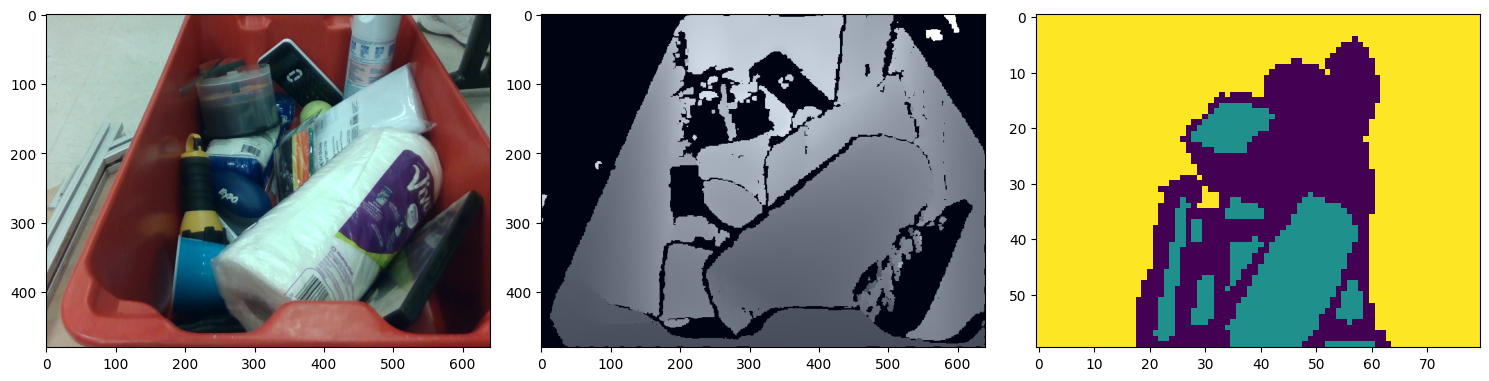

In [6]:
color_img_vis = torch.movedim(color_batch[0] * 0.229 + 0.485, 0, 2)
depth_img_vis = torch.movedim(depth_batch[0] * 0.229 + 0.485, 0, 2)
label_vis = label_batch[1] / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(color_img_vis)
axes[1].imshow(depth_img_vis)
axes[2].imshow(label_vis)
plt.tight_layout()
plt.show()

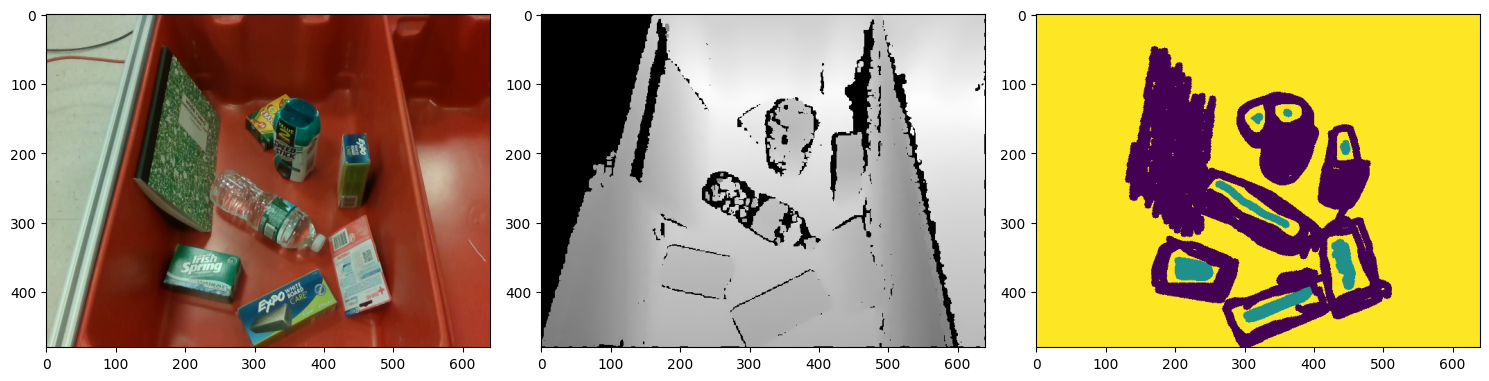

In [20]:
raw_dataset = SuctionGraspingDataset(
    data_path='../data',
    sample_list='../data/train-split.txt',
    transform=None
)
color_img, depth_img, label_img = raw_dataset[4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(color_img)
axes[1].imshow(depth_img, cmap="gray")
axes[2].imshow(label_img)
plt.tight_layout()
plt.show()

## Testing the model

In [ ]:
from model import RGBDResNet101
from metrics import masked_bce_loss

In [ ]:
num_classes = 1
torch.cuda.empty_cache()
model = RGBDResNet101(num_classes=num_classes, pretrained=True).to(device)
model.eval();

In [13]:
with torch.no_grad():
    output = model(color_batch.to(device), depth_batch.to(device))
    loss = masked_bce_loss(output, label_batch.to(device))
print(f"Output shape: {output.shape}")
print(f"Labels shape: {label_batch.shape}")
print(f"Loss: {loss.cpu().item()}")

Output shape: torch.Size([4, 1, 60, 80])
Labels shape: torch.Size([4, 60, 80])
Loss: 0.6471605896949768


## Visualizing inference

In [ ]:
torch.cuda.empty_cache()
try:
    weights = "snapshots/snapshot-5000.pt"
    model = RGBDResNet101(num_classes=1, pretrained=False)
    checkpoint = torch.load(weights, map_location=device, weights_only=True)
    if 'optimizer' in checkpoint and 'model' in checkpoint:
        checkpoint = checkpoint['model']
    model.load_state_dict(checkpoint)
except Exception:
    print("Couldn't load weights. Using weights from pretraining on ImageNet")
    model = RGBDResNet101(num_classes=1, pretrained=True)
model = model.to(device).eval()

In [ ]:
color_img, depth_img, label_img = raw_dataset[4]
color, depth, label = data_transform(color_img, depth_img, label_img)

with torch.no_grad():
    color = color[None].to(device)
    depth = depth[None].to(device)
    output = F.sigmoid(model(color, depth))

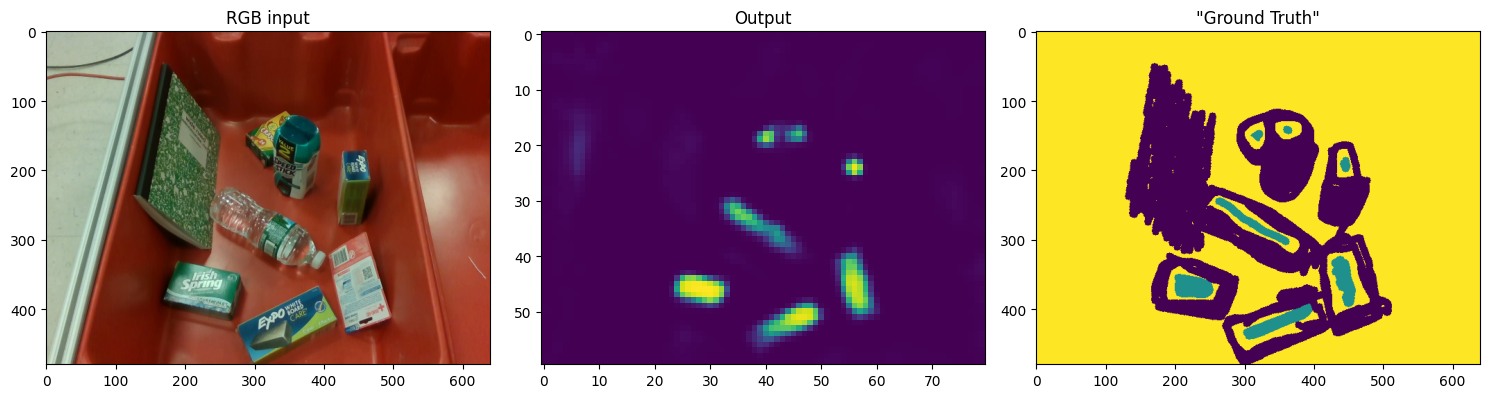

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title('RGB input')
axes[0].imshow(color_img)
axes[1].set_title('Output')
axes[1].imshow(output[0, 0].cpu().numpy())
axes[2].set_title('"Ground Truth"')
axes[2].imshow(label_img)
plt.tight_layout()
plt.show()

In [ ]:
# width, height = color_img.size
# output_resized = TF.resize(output, [height, width])  # [1, 1, H, W]

# output_np = output.cpu().squeeze().numpy()
# Image.fromarray((output_np * 255).astype(np.uint8), mode='L')

In [34]:
!nvidia-smi

Mon May  4 13:19:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1070 Ti     Off |   00000000:01:00.0  On |                  N/A |
| 63%   84C    P2            113W /  180W |    4564MiB /   8192MiB |     99%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
del model
torch.cuda.empty_cache()

## Model summary

In [18]:
class ResNet2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = RGBDResNet101(num_classes=3)
    def forward(self, x):
        return self.model(x[0], x[1])

In [19]:
from torchinfo import summary

summary(ResNet2(), input_size=(2, 4, 3, 480, 640))

Layer (type:depth-idx)                             Output Shape              Param #
ResNet2                                            [4, 3, 60, 80]            --
├─RGBDResNet101: 1-1                               [4, 3, 60, 80]            --
│    └─Sequential: 2-1                             [4, 1024, 30, 40]         --
│    │    └─Conv2d: 3-1                            [4, 64, 240, 320]         9,408
│    │    └─BatchNorm2d: 3-2                       [4, 64, 240, 320]         (128)
│    │    └─ReLU: 3-3                              [4, 64, 240, 320]         --
│    │    └─MaxPool2d: 3-4                         [4, 64, 120, 160]         --
│    │    └─Sequential: 3-5                        [4, 256, 120, 160]        215,808
│    │    └─Sequential: 3-6                        [4, 512, 60, 80]          1,219,584
│    │    └─Sequential: 3-7                        [4, 1024, 30, 40]         26,090,496
│    └─Sequential: 2-2                             [4, 1024, 30, 40]         --
│    │   